In [ ]:
## Let's go through the entire pipeline, for a single mesh. Checking each step of the process.
from pathlib import Path
import pandas as pd
import sys
import re

# Add parent directory to sys.path
parent_dir = str(Path.cwd().parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
import cross_section_helpers as csh

chosen_mesh = ["1_2"]
colours = {
    'realistic': 'blue',
    'simplified_circular': 'orange',
    'simplified_oval': 'green'
}

## Load in the results
path_to_data = "../Meshes/"
confocal_results = "Onion meshes/pressure_pore/"
confocal_meshes = "Onion meshes/pressure_results/"
idealised_results = "Idealised/pressure_pore/"
idealised_meshes = "Idealised/pressure_results/"

## Define the pattern for the file names
mesh_file_pattern = r"Ac_DA_([^_]+_[^_]+)_([0-9]+\.?[0-9]*)\.obj"
results_file_pattern = r"pore_area_Ac_DA_([^_]+_[^_]+)\.txt"

def extract_id_and_pressure(filename, pattern):
    """
    Extract ID and pressure from filename using the defined pattern.
    
    Args:
        filename (str): Filename like "Ac_DA_1_2_0.0.obj"
    
    Returns:
        tuple: (id, pressure) or (None, None) if no match
    """
    match = re.search(pattern, str(filename))
    if match:
        id_part = match.group(1)  # e.g., "1_2"
        if len(match.groups()) > 1:
            pressure = float(match.group(2))  # e.g., 0.0
            return (id_part, pressure)
        else:
            return (id_part, None)
    return (None, None)

## Get all files in the folder
confocal_results_files = [f for f in Path(path_to_data + confocal_results).glob("*.txt")]
confocal_mesh_files = [f for f in Path(path_to_data + confocal_meshes).glob("*.obj")]

## Load in the data for the idealised meshes
idealised_results_files = [f for f in Path(path_to_data + idealised_results).glob("*.txt")]
idealised_mesh_files = [f for f in Path(path_to_data + idealised_meshes).glob("*.obj")]

## Keep only the chosen mesh values - FIXED VERSION
chosen_confocal_results_files = [f for f in confocal_results_files if extract_id_and_pressure(f.name, results_file_pattern)[0] in chosen_mesh]
chosen_confocal_mesh_files = [f for f in confocal_mesh_files if extract_id_and_pressure(f.name, mesh_file_pattern)[0] in chosen_mesh]
chosen_idealised_results_files = [f for f in idealised_results_files if extract_id_and_pressure(f.name, results_file_pattern)[0] in chosen_mesh]
chosen_idealised_mesh_files = [f for f in idealised_mesh_files if extract_id_and_pressure(f.name, mesh_file_pattern)[0] in chosen_mesh]

In [24]:
chosen_confocal_mesh_files

[]

In [2]:
## Populate the two dataframes
import importlib
import mesh_functions
importlib.reload(mesh_functions)  # Reload to get the latest changes
import pandas as pd
from mesh_functions import process_mesh
from concurrent.futures import ThreadPoolExecutor, as_completed

confocal_results_chosen = []
with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_mesh, file) for file in chosen_confocal_mesh_files]
    for future in as_completed(futures):
        confocal_results_chosen.append(future.result())

df_chosen = pd.DataFrame(confocal_results_chosen)


In [4]:
## Add in volume and pore area to the dataframe
import trimesh
import numpy as np
import mesh_functions as mf
importlib.reload(mesh_functions)  # Reload to get the latest changes
import pandas as pd

pressures = np.arange(0,2.1, 0.1)
df_full = mf.get_pore_area_and_volume(df_chosen, chosen_confocal_results_files[0], chosen_confocal_mesh_files, pressures)
display(df_full.head(5))

,Mesh ID,Cross-section type,Pressure,Midsection AR left,Midsection AR right,Midsection Points Left,Midsection Points Right,Tip AR left,Tip AR right,Tip Points Left,Tip Points Right,Major length left,Major length right,Minor length left,Minor length right,Pore Area,Volume
0,1_2,confocal,0.1,1.214941,1.266045,"[[-13.662724405559624, 2.0697517879248077, -5....","[[7.301126278253118, 0.0643581342282297, -4.47...",1.093258,1.144805,"[[0.7295981482904699, -5.509246261944273, -1.4...","[[2.554882039348747, 6.525504056002124, 2.6897...",14.785460,15.955745,12.169694,12.602829,51.38,11946.035510
1,1_2,confocal,1.3,1.005229,1.081492,"[[-9.556449393941524, 1.9708555193429207, -7.5...","[[20.815357130334405, -1.41166354973275, -0.82...",1.028984,1.093794,"[[-1.0880025622496978, -8.863339621810992, 4.1...","[[2.334734213382744, 6.517776080695615, 0.0560...",14.421564,15.935932,14.346541,14.735137,61.76,14174.291512
2,1_2,confocal,1.5,1.004519,1.071766,"[[-2.2835220873669697, 0.6754736857717474, -1....","[[20.830716261167556, -1.3640256072482098, -1....",1.027216,1.081368,"[[-7.01440154409436, -18.54852416201539, -0.00...","[[5.521921307652205, 12.76157262786778, 9.3355...",14.574151,16.038309,14.508588,14.964382,62.28,14515.114811
3,1_2,confocal,1.7,1.001043,1.064699,"[[-17.331187713810685, 1.8098731405006567, 0.2...","[[18.603516701350355, -0.825084285882833, -5.5...",1.019882,1.077606,"[[-2.982375616152505, -12.073347605768571, 6.1...","[[3.0387176696110654, 7.685732544498201, 5.526...",14.703583,16.162133,14.688262,15.180001,62.60,14858.666072
4,1_2,confocal,1.6,0.999384,1.070289,"[[-13.711348848650589, 0.9681302218718966, 5.3...","[[5.209600838029597, 0.005210482577451825, -2....",1.021888,1.079732,"[[-7.07327073527985, -18.612763709142, -0.1530...","[[5.414404488548417, 12.522897903386074, -4.96...",14.614279,16.120748,14.623288,15.062054,62.40,14686.489640


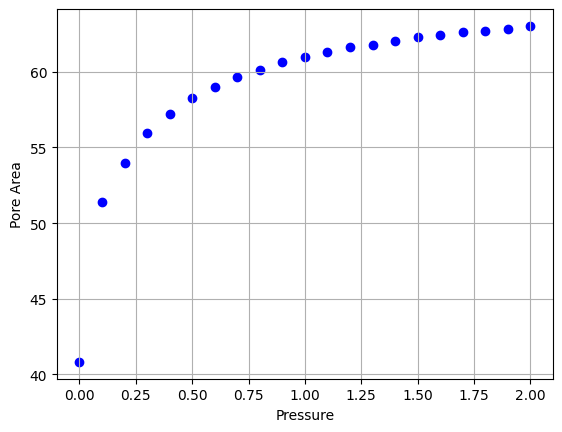

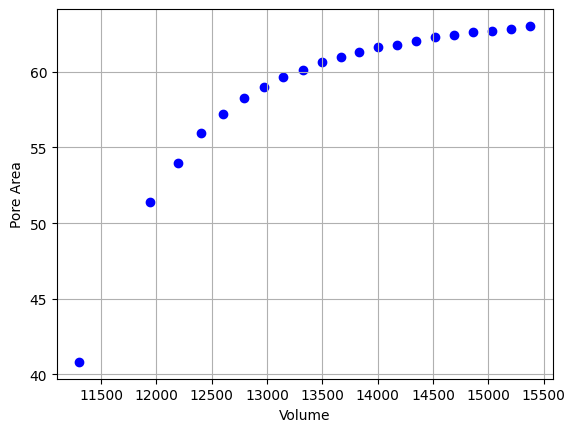

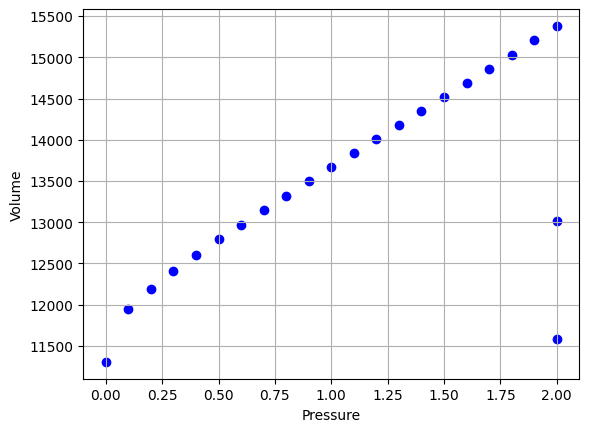

In [9]:
## Plot pressure vs pore area
import matplotlib.pyplot as plt

plt.scatter(df_full['Pressure'], df_full['Pore Area'], marker='o', color='blue')
plt.xlabel('Pressure')
plt.ylabel('Pore Area')
plt.grid(True)
plt.show()

## Plot volume vs pore area
plt.scatter(df_full['Volume'], df_full['Pore Area'], marker='o', color='blue')
plt.xlabel('Volume')
plt.ylabel('Pore Area')
plt.grid(True)
plt.show()

## Plot pressure vs volume
plt.scatter(df_full['Pressure'], df_full['Volume'], marker='o', color='blue')
plt.xlabel('Pressure')
plt.ylabel('Volume')
plt.grid(True)
plt.show()



In [10]:
df_full[df_full["Pressure"] == 2.0]

,Mesh ID,Cross-section type,Pressure,Midsection AR left,Midsection AR right,Midsection Points Left,Midsection Points Right,Tip AR left,Tip AR right,Tip Points Left,Tip Points Right,Major length left,Major length right,Minor length left,Minor length right,Pore Area,Volume
14,2_1,confocal,2.0,1.002280,0.994843,"[[-4.07552392085698, 7.462726844454577, -11.92...","[[8.821773682456312, 5.498555304243443, -8.187...",1.061234,1.026819,"[[0.6041591706401302, 1.491129929515461, -5.03...","[[5.918715043694377, 11.922233808233129, -8.34...",13.310418,13.427156,13.280137,13.496756,NaN,11579.410851
15,3_1,confocal,2.0,0.972212,0.996259,"[[-10.75197751625303, -1.5090728496600436, 6.4...","[[15.999995786507373, 2.8905864982664338, 4.34...",0.981848,1.147804,"[[-0.35753315391918905, -6.298767323731429, 2....","[[2.618870313008508, 13.097304762178535, 8.918...",14.599008,14.636434,15.016286,14.691388,NaN,13009.029726
16,1_2,confocal,2.0,0.995295,1.056433,"[[-4.318682753861049, 1.1711100449512761, -5.5...","[[17.781780866447807, -0.7717668830696802, -6....",1.013092,1.069745,"[[-1.8380786519677184, -9.585897415339065, -7....","[[2.915844187899481, 7.170743860984672, -1.355...",14.893548,16.358835,14.963950,15.484966,63.03,15381.000106
